# 🔢 MNIST Digit Classification with Deep Learning

## Project Overview
This notebook demonstrates a complete machine learning pipeline for **handwritten digit classification** using the MNIST dataset. We explore two neural network architectures:

1. **Baseline Dense Neural Network** - A simple fully-connected architecture
2. **Convolutional Neural Network (CNN)** - A more sophisticated model with data augmentation

## Dataset
The **MNIST dataset** consists of 70,000 grayscale images of handwritten digits (0-9):
- **Training set**: 60,000 images (28×28 pixels)
- **Test set**: 10,000 images (28×28 pixels)

## Workflow
1. **Data Loading & Preprocessing** - Load MNIST, normalize pixel values
2. **Exploratory Data Analysis (EDA)** - Check data quality and distribution
3. **Baseline Model** - Train a Dense NN for baseline performance
4. **Data Augmentation** - Apply image transformations to improve generalization
5. **CNN Model** - Train an optimized CNN architecture
6. **Model Evaluation** - Compare performance metrics

---
**Author**: Osama Abd El Mohsen  
**Framework**: TensorFlow/Keras  
**Last Updated**: 2026

## 1. Import Libraries

Import all necessary dependencies for:
- **Data manipulation**: NumPy, Pandas
- **Visualization**: Matplotlib, Seaborn  
- **Deep Learning**: TensorFlow/Keras
- **Model persistence**: Joblib

In [1]:
from matplotlib import pyplot as plt
import tensorflow as tf
import seaborn as sns
import pandas as pd
import numpy as np

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D , Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping 
from tensorflow.keras.optimizers import Adam

import joblib

from utils import show_img,classification_model_measurements

random_seed = 42

## 2. Data Loading & Preprocessing

Load the MNIST dataset directly from TensorFlow/Keras and apply normalization.

**Normalization**: Pixel values are scaled from [0, 255] to [0, 1] by dividing by 255. This:
- Speeds up gradient descent convergence
- Prevents large values from dominating the learning process
- Ensures consistent feature scales

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# Scaling
X_train = X_train / 255.0
X_test = X_test / 255.0

In [3]:
print("X_train.shape  => ",X_train.shape)
print("X_test.shape  => ",X_test.shape)
print("y_train.shape  => ",y_train.shape)
print("y_test.shape  => ",y_test.shape)

X_train.shape  =>  (60000, 28, 28)
X_test.shape  =>  (10000, 28, 28)
y_train.shape  =>  (60000,)
y_test.shape  =>  (10000,)


## 3. Exploratory Data Analysis (EDA)

### 3.1 Missing Values Check
Verify data integrity by checking for any null or NaN values in the dataset.

In [4]:
np.isnan(X_train).any(),np.isnan(X_test).any()

(np.False_, np.False_)

### 3.2 Class Distribution Analysis
Examine the distribution of digit classes to ensure a balanced dataset. An imbalanced dataset could bias the model towards majority classes.

In [5]:
values, counts = np.unique(y_train, return_counts=True)
print("Training set labels and counts:", values, counts)

values, counts = np.unique(y_test, return_counts=True)
values, counts
print("Test set labels and counts:", values, counts)

Training set labels and counts: [0 1 2 3 4 5 6 7 8 9] [5923 6742 5958 6131 5842 5421 5918 6265 5851 5949]
Test set labels and counts: [0 1 2 3 4 5 6 7 8 9] [ 980 1135 1032 1010  982  892  958 1028  974 1009]


### 3.3 Data Visualization
Display sample images from the training set to understand the visual characteristics of handwritten digits.

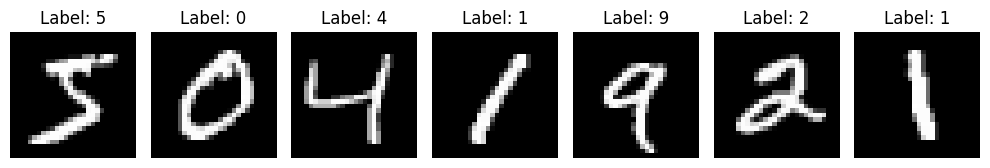

In [6]:
show_img(X_train,y_train,7)

## 4. Label Encoding

### 4.1 Original Labels
The target labels are integers from 0-9 representing each digit class.

In [7]:
y_test[0:5]

array([7, 2, 1, 0, 4], dtype=uint8)

### 4.2 One-Hot Encoding
Convert integer labels to one-hot encoded vectors for multi-class classification.

**Why One-Hot Encoding?**
- Neural networks with softmax output expect categorical target vectors
- Prevents the model from assuming ordinal relationships between classes (e.g., 9 is not "greater" than 1)
- Each digit becomes a 10-dimensional binary vector (e.g., digit 3 → [0,0,0,1,0,0,0,0,0,0])

In [8]:
y_train = to_categorical(y_train, num_classes = 10)
y_test = to_categorical(y_test, num_classes = 10)
y_test[0:5]

array([[0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]])

## 5. Baseline Model: Dense Neural Network

Build a simple fully-connected (Dense) neural network as a baseline model.

### Architecture
- **Input**: Flatten 28×28 image → 784 features
- **Hidden Layer 1**: 128 neurons + ReLU + Dropout (30%)
- **Hidden Layer 2**: 64 neurons + ReLU + Dropout (30%)
- **Output**: 10 neurons + Softmax (probability distribution over 10 classes)

### Training Configuration
- **Loss**: Categorical Cross-Entropy (standard for multi-class classification)
- **Optimizer**: Adam (adaptive learning rate)
- **Early Stopping**: Monitor validation loss, restore best weights

In [12]:
early_stop  = EarlyStopping(monitor='val_loss', patience=3 ,restore_best_weights=True)

In [11]:
model = Sequential(
    [
        Flatten(input_shape=(28, 28 )),
        Dense(units = 128,activation = 'relu'),
        Dropout(0.3),
        Dense(units = 64,activation = 'relu'),
        Dropout(0.3),
        Dense(units = 10,activation = 'softmax'),
    ]
)

model.compile(
    loss = 'categorical_crossentropy' , 
    optimizer='Adam',
    metrics=['accuracy'] ,
)


In [13]:
history = model.fit(
    X_train,
    y_train,
    batch_size=128,
    epochs=50,
    validation_split=0.2,
    callbacks = [early_stop],
    verbose=1
)

Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8260 - loss: 0.5690 - val_accuracy: 0.9426 - val_loss: 0.2002
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9271 - loss: 0.2545 - val_accuracy: 0.9578 - val_loss: 0.1446
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9412 - loss: 0.2037 - val_accuracy: 0.9628 - val_loss: 0.1222
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9496 - loss: 0.1715 - val_accuracy: 0.9655 - val_loss: 0.1107
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9568 - loss: 0.1479 - val_accuracy: 0.9691 - val_loss: 0.1062
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9606 - loss: 0.1339 - val_accuracy: 0.9710 - val_loss: 0.0988
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9630 - loss: 0.1223 - val_accuracy: 0.9737 - val_loss: 0.0905
Epoch 8/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9676 - loss: 0.1081 - val_accuracy: 0.

### 5.1 Model Evaluation (Baseline)
Evaluate the Dense NN performance on both training and test sets.

In [14]:
y_t_pred = model.predict(X_train)
y_pred = model.predict(X_test)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [15]:
y_test_labels = np.argmax(y_test, axis=1)
y_pred_labels = np.argmax(y_pred, axis=1)
y_train_labels = np.argmax(y_train, axis=1)
y_t_pred_labels = np.argmax(y_t_pred, axis=1)
classification_model_measurements(y_train_labels,y_t_pred_labels,y_test_labels,y_pred_labels)

************ MODEL EVALUATION METRICS ************

                  ACCURACY SCORE                  
--------------------------------------------------
Training  => 98.94%
Testing   => 97.63%

                 CONFUSION MATRIX                 
--------------------------------------------------
Training:
[[5892    0    5    2    1    2   11    2    6    2]
 [   0 6700    9    6    4    0    4    6   13    0]
 [   5    3 5918    5    3    1    1   17    4    1]
 [   1    0   39 6033    0   26    0   14    8   10]
 [   1    8    7    0 5790    0    2    4    1   29]
 [   7    2    8   38    1 5330   16    0    9   10]
 [   9    1    1    0    6    8 5889    0    4    0]
 [   2    9   25    5    7    0    0 6206    1   10]
 [   6   17   12   17    3    9    7    3 5770    7]
 [   7    6    1   18   29    9    0   33   12 5834]]

Testing:
[[ 970    0    2    0    0    2    3    1    2    0]
 [   0 1124    3    1    0    1    3    0    3    0]
 [   4    0 1016    2    1    0    1    5    3

## 6. Data Augmentation

Data augmentation artificially expands the training dataset by applying random transformations to images. This helps:

- **Reduce overfitting** by exposing the model to more variations
- **Improve generalization** to unseen handwriting styles
- **Simulate real-world variations** in digit appearance

### Transformations Applied
| Transformation | Value | Purpose |
|----------------|-------|---------|
| Rotation | ±10° | Handle tilted digits |
| Zoom | ±10% | Handle size variations |
| Width Shift | ±10% | Handle horizontal positioning |
| Height Shift | ±10% | Handle vertical positioning |

### Reshape for CNN
Images must be reshaped from (28, 28) to (28, 28, 1) to include the channel dimension required by Conv2D layers.

In [16]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1,28,28,1)

In [17]:
X_train.shape,X_test.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,  
    zoom_range = 0.10,  
    width_shift_range=0.1, 
    height_shift_range=0.1
)

datagen.fit(X_train)

### 6.1 Visualize Augmented Images
Display samples of augmented images to verify the transformations are applied correctly.

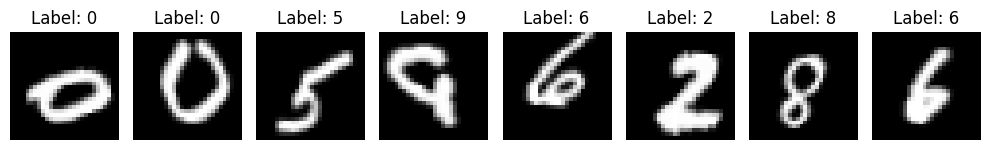

In [20]:
import matplotlib.pyplot as plt
import numpy as np

augmented_images, augmented_labels = next(
    datagen.flow(X_train, y_train, batch_size=8)
)
augmented_labels = [np.argmax(x) for x in augmented_labels]

show_img(augmented_images,augmented_labels,8)

## 7. Convolutional Neural Network (CNN)

CNNs are specifically designed for image data and outperform Dense networks by:


### Architecture
```
Block 1: Conv2D(32) → BatchNorm → Conv2D(32) → BatchNorm → MaxPool → Dropout(25%)
Block 2: Conv2D(64) → BatchNorm → Conv2D(64) → BatchNorm → MaxPool → Dropout(25%)
Classification: Flatten → Dense(128) → BatchNorm → Dropout(50%) → Softmax(10)
```

### Key Components
- **Conv2D**: Extract local features using 3×3 learnable filters
- **BatchNormalization**: Normalize activations for faster, more stable training  
- **MaxPooling2D**: Downsample spatial dimensions, retain important features
- **Dropout**: Regularization to prevent overfitting

In [21]:
early_stop  = EarlyStopping(monitor='val_loss', patience=3 ,restore_best_weights=True)

In [26]:
model = Sequential([
    
    # Block 1
    Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(28,28,1)),
    BatchNormalization(),
    Conv2D(32, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Classification Head
    Flatten(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

d:\Programming\ai-practice\02 MINST Dataset\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
model.compile(
    optimizer='Adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [28]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    epochs=10,
    validation_data=(X_test, y_test),
    callbacks = [early_stop]
)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 71s 71ms/step - accuracy: 0.9080 - loss: 0.2972 - val_accuracy: 0.9881 - val_loss: 0.0346
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 59s 63ms/step - accuracy: 0.9672 - loss: 0.1065 - val_accuracy: 0.9899 - val_loss: 0.0305
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 59s 63ms/step - accuracy: 0.9753 - loss: 0.0820 - val_accuracy: 0.9857 - val_loss: 0.0468
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 64s 68ms/step - accuracy: 0.9786 - loss: 0.0710 - val_accuracy: 0.9896 - val_loss: 0.0335
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 61s 65ms/step - accuracy: 0.9804 - loss: 0.0637 - val_accuracy: 0.9936 - val_loss: 0.0177
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 67s 71ms/step - accuracy: 0.9816 - loss: 0.0615 - val_accuracy: 0.9930 - val_loss: 0.0229
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 78s 83ms/step - accuracy: 0.9846 - loss: 0.0508 - val_accuracy: 0.9933 - val_loss: 0.0197
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 69s 73ms/step - accuracy: 0.9852 - loss: 0.0488 - 

In [29]:
y_t_pred = model.predict(X_train)
y_pred = model.predict(X_test)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


### 7.1 Model Evaluation
Evaluate the CNN model performance using accuracy, confusion matrix, and classification report.

In [30]:
y_test_labels = np.argmax(y_test, axis=1)
y_pred_labels = np.argmax(y_pred, axis=1)
y_train_labels = np.argmax(y_train, axis=1)
y_t_pred_labels = np.argmax(y_t_pred, axis=1)
classification_model_measurements(y_train_labels,y_t_pred_labels,y_test_labels,y_pred_labels)

************ MODEL EVALUATION METRICS ************

                  ACCURACY SCORE                  
--------------------------------------------------
Training  => 99.50%
Testing   => 99.54%

                 CONFUSION MATRIX                 
--------------------------------------------------
Training:
[[5894    1    0    0    0    2   15    0   11    0]
 [   0 6724    2    1    0    0    3   11    0    1]
 [   0    2 5931    4    0    2    0   10    7    2]
 [   0    0    2 6104    0    6    0    4   10    5]
 [   0    3    0    0 5790    0    4    3    2   40]
 [   1    2    0    9    0 5375   10    0   19    5]
 [   1    0    0    1    3    4 5900    0    9    0]
 [   0    4    5    0    5    0    0 6228    1   22]
 [   1    2    4    2    2    1    0    3 5826   10]
 [   1    2    0    2    9    1    0    1    7 5926]]

Testing:
[[ 975    0    0    0    0    0    3    0    1    1]
 [   0 1130    1    1    0    0    2    1    0    0]
 [   0    0 1028    1    0    0    1    1    1

In [ ]:
# joblib.dump(model, "../model/mnist_model.pkl")

['../model/mnist_model.pkl']

## 8. Model Export & Conclusion

### Summary
| Model | Architecture | Key Features | Expected Accuracy |
|-------|-------------|--------------|-------------------|
| **Baseline Dense NN** | Flatten → Dense(128) → Dense(64) → Softmax | Simple, fast training | ~97% |
| **CNN** | Conv2D blocks + Dense head | Spatial feature learning, data augmentation | ~99.5% |

### Key Takeaways
1. **Data preprocessing** (normalization, one-hot encoding) is essential for neural network training
2. **CNNs significantly outperform** Dense networks on image classification tasks
3. **Data augmentation** helps prevent overfitting and improves generalization
4. **Batch normalization and Dropout** are effective regularization techniques

---
**Next Steps**: The trained model is deployed via the Streamlit app in `app/app.py` for interactive digit prediction.